<a href="https://colab.research.google.com/github/Sumant-crty/Insight/blob/main/MainwarehousevehicleANPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
opencv-python
easyocr

Processing image... please wait.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- DETECTION RESULTS ---
Detected Plate: 22 BH65174
Confidence Score: 0.54
Detected Plate: SHUTTERSTOCK COM
Confidence Score: 0.67
Detected Plate: 2144472845
Confidence Score: 0.94


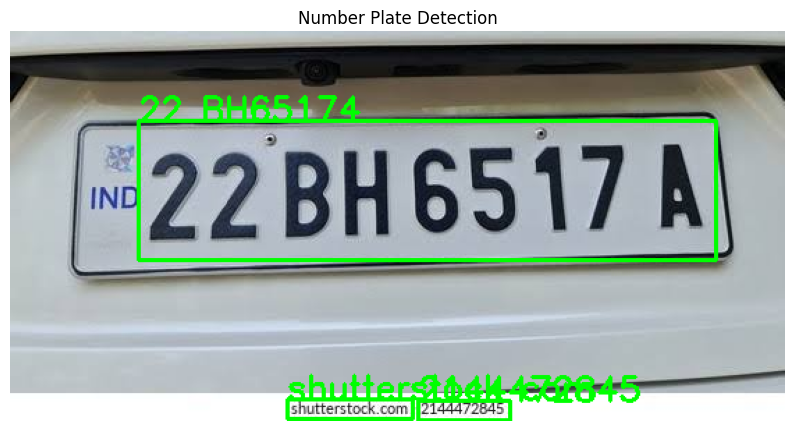

In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# 1. Initialize the Reader (English language)
# 'gpu=False' if you don't have an NVIDIA graphics card
reader = easyocr.Reader(['en'], gpu=False)

# 2. Load your image
image_path = 'test_image.jpeg'
image = cv2.imread(image_path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}.")
    print("Please ensure the image file exists and the path is correct.")
else:
    # 3. Perform OCR
    print("Processing image... please wait.")
    results = reader.readtext(image)

    # 4. Display Results
    print("\n--- DETECTION RESULTS ---")
    for (bbox, text, prob) in results:
        # We filter for text length to avoid reading small stickers/logos
        if len(text) > 5:
            print(f"Detected Plate: {text.upper()}")
            print(f"Confidence Score: {prob:.2f}")

    # Optional: Draw a box around the plate and show it
    display_image = image.copy() # Make a copy to draw on
    for (bbox, text, prob) in results:
        if len(text) > 5:
            (tl, tr, br, bl) = bbox
            cv2.rectangle(display_image, tuple(map(int, tl)), tuple(map(int, br)), (0, 255, 0), 2)
            cv2.putText(display_image, text, tuple(map(int, tl)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Display the image using matplotlib for Colab compatibility
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title("Number Plate Detection")
    plt.axis('off')
    plt.show()


In [ ]:
pip install opencv-python easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 18.9 MB/s eta 0:00:00
